In [2]:
!python --version

Python 3.14.7


In [1]:
import requests
import pandas as pd
from tqdm import tqdm

In [5]:
def fetch_steam_reviews(appid, game_name, num_pages=50):
    all_reviews = []
    cursor = "*"
    i=0

    for _ in tqdm(range(num_pages), desc=f"Fetching {game_name}"):
        url = f"https://store.steampowered.com/appreviews/{appid}"
        params = {
            "json": 1,
            "language": "english",
            "filter": "recent",
            "purchase_type": "all",
            "num_per_page": 100,
            "cursor": cursor
        }

        response = requests.get(url, params=params)
        if response.status_code != 200:
            break

        data = response.json()
        if i==0:
            print(data)
            i=1
        reviews = data.get("reviews", [])

        if not reviews:
            break

        for r in reviews:
            author = r.get("author", {})

            all_reviews.append({
                "appid": appid,
                "game_name": game_name,
                "review_id": r.get("recommendationid"),
                "review_text": r.get("review"),
                "recommendation": r.get("voted_up"),
            })

        new_cursor = data.get("cursor")
        if not new_cursor or new_cursor == cursor:
            break
        cursor = new_cursor
    return pd.DataFrame(all_reviews)

In [6]:
appid_dict = {
    2807960: "Battlefield™ 6",
    524220: "NieR:Automata™",
    620: "Portal 2",
    976310: "Mortal Kombat 11",
    2050650: "Resident Evil 4",
    1091500: "Cyberpunk 2077",
    1328670: "Mass Effect™ Legendary Edition",
    292030: "The Witcher 3: Wild Hunt",
    1245620: "ELDEN RING",
    1551360: "Forza Horizon 5",
    236390: "War Thunder",
    1687950: "Persona 5 Royal",
    730: "Counter-Strike 2",
    1506830: "FIFA 22",
    281990: "Stellaris",
    1601570: "The Alters",
    367520: "Hollow Knight",
    1388880: "Doki Doki Literature Club Plus!",
}

In [7]:
all_dfs = []

for appid, game_name in appid_dict.items():
    df = fetch_steam_reviews(appid, game_name, num_pages=75)
    all_dfs.append(df)

print(all_dfs)

Fetching Battlefield™ 6:   1%|▏         | 1/75 [00:00<00:57,  1.29it/s]

{'success': 1, 'query_summary': {'num_reviews': 100, 'review_score': 5, 'review_score_desc': 'Mixed', 'total_positive': 121771, 'total_negative': 60389, 'total_reviews': 182160}, 'reviews': [{'recommendationid': '234286232', 'author': {'steamid': '76561198038945093', 'personaname': 'Wastedkornkid666', 'persona_status': 'in-game', 'profile_url': 'https://steamcommunity.com/profiles/76561198038945093/', 'num_games_owned': 148, 'num_reviews': 3, 'playtime_forever': 18098, 'playtime_last_two_weeks': 24, 'playtime_at_review': 18098, 'last_played': 1788248227, 'avatar': '54be38c13d0e7792de2af9a76c4e376766cf697a'}, 'language': 'english', 'review': "Pre ordered the game to be locked out due to a anti cheat change that didn't work 12 months later, steam are refusing to refund. If anyone else has had this issue i'm currently engaging a law firm for a potetial class action againt both Valve and ea.", 'timestamp_created': 1788329941, 'timestamp_updated': 1788329941, 'voted_up': False, 'votes_up': 

Fetching NieR:Automata™:   1%|▏         | 1/75 [00:00<01:05,  1.13it/s]

{'success': 1, 'query_summary': {'num_reviews': 100, 'review_score': 8, 'review_score_desc': 'Very Positive', 'total_positive': 58019, 'total_negative': 6410, 'total_reviews': 64429}, 'reviews': [{'recommendationid': '234257413', 'author': {'steamid': '76561199590132691', 'personaname': 'zens2465', 'persona_status': 'offline', 'profile_url': 'https://steamcommunity.com/profiles/76561199590132691/', 'num_games_owned': 62, 'num_reviews': 7, 'playtime_forever': 1452, 'playtime_last_two_weeks': 903, 'playtime_at_review': 1452, 'last_played': 1788291970, 'avatar': 'bab8f8237936411bd6008b06f20c9c5a337be00f'}, 'language': 'english', 'review': 'I finished the game and deleted my data. If you wish to know why play the game', 'timestamp_created': 1788291918, 'timestamp_updated': 1788291918, 'voted_up': True, 'votes_up': 0, 'votes_funny': 0, 'weighted_vote_score': 0.5, 'comment_count': 0, 'steam_purchase': True, 'received_for_free': False, 'refunded': False, 'written_during_early_access': False, 

Fetching Portal 2:   1%|▏         | 1/75 [00:00<01:00,  1.22it/s]

{'success': 1, 'query_summary': {'num_reviews': 100, 'review_score': 9, 'review_score_desc': 'Overwhelmingly Positive', 'total_positive': 208560, 'total_negative': 2467, 'total_reviews': 211027}, 'reviews': [{'recommendationid': '234282138', 'author': {'steamid': '76561198091964306', 'personaname': 'Mr.Chinsley', 'persona_status': 'offline', 'profile_url': 'https://steamcommunity.com/id/breadmier/', 'num_games_owned': 536, 'num_reviews': 6, 'playtime_forever': 1000, 'playtime_last_two_weeks': 107, 'playtime_at_review': 1000, 'deck_playtime_at_review': 367, 'last_played': 1788291244, 'avatar': '39fa927b3948d1d5a44f5c022d0c220c8261352e'}, 'language': 'english', 'review': 'Absolute classic. I replay both of them at least once a year. Not to mention the fan games this series spawned is insane.', 'timestamp_created': 1788322659, 'timestamp_updated': 1788322659, 'voted_up': True, 'votes_up': 0, 'votes_funny': 0, 'weighted_vote_score': 0.5, 'comment_count': 0, 'steam_purchase': False, 'receiv

Fetching Mortal Kombat 11:   1%|▏         | 1/75 [00:00<01:11,  1.03it/s]

{'success': 1, 'query_summary': {'num_reviews': 100, 'review_score': 8, 'review_score_desc': 'Very Positive', 'total_positive': 31489, 'total_negative': 5018, 'total_reviews': 36507}, 'reviews': [{'recommendationid': '234257160', 'author': {'steamid': '76561198111089601', 'personaname': 'AlexeyM', 'persona_status': 'offline', 'profile_url': 'https://steamcommunity.com/profiles/76561198111089601/', 'num_games_owned': 0, 'num_reviews': 7, 'playtime_forever': 2114, 'playtime_last_two_weeks': 2114, 'playtime_at_review': 2114, 'last_played': 1788291677, 'avatar': '48459bef383b054041afb5540af063487334912a'}, 'language': 'english', 'review': 'Nice game! I like it!', 'timestamp_created': 1788291697, 'timestamp_updated': 1788291697, 'voted_up': True, 'votes_up': 0, 'votes_funny': 0, 'weighted_vote_score': 0.5, 'comment_count': 0, 'steam_purchase': False, 'received_for_free': False, 'refunded': False, 'written_during_early_access': False, 'primarily_steam_deck': False, 'app_release_date': '15560

Fetching Resident Evil 4:   1%|▏         | 1/75 [00:00<00:57,  1.28it/s]

{'success': 1, 'query_summary': {'num_reviews': 100, 'review_score': 9, 'review_score_desc': 'Overwhelmingly Positive', 'total_positive': 93384, 'total_negative': 3446, 'total_reviews': 96830}, 'reviews': [{'recommendationid': '234283891', 'author': {'steamid': '76561198002879589', 'personaname': '[Tom Jr]', 'persona_status': 'online', 'profile_url': 'https://steamcommunity.com/id/dayspring88/', 'num_games_owned': 261, 'num_reviews': 5, 'playtime_forever': 11135, 'playtime_last_two_weeks': 3679, 'playtime_at_review': 11095, 'deck_playtime_at_review': 856, 'last_played': 1788328280, 'avatar': 'aaa7a426c5b404e17889ac749667c721d738b5f1'}, 'language': 'english', 'review': "I played RE4 when it released for the GC way back when. Loved the gameplay, the styling and the plot. There are some changes in this game from the original that didn't feel like RE4, but a whole lot of improvements that make the game just as fun. I highly recommend this game if you are a RE4 fan or looking for a great re

Fetching Cyberpunk 2077:   1%|▏         | 1/75 [00:00<00:52,  1.40it/s]

{'success': 1, 'query_summary': {'num_reviews': 100, 'review_score': 8, 'review_score_desc': 'Very Positive', 'total_positive': 370491, 'total_negative': 46136, 'total_reviews': 416627}, 'reviews': [{'recommendationid': '234288262', 'author': {'steamid': '76561198096573191', 'personaname': 'MozziesShockDrone', 'persona_status': 'offline', 'profile_url': 'https://steamcommunity.com/id/MozziesShockDrone/', 'num_games_owned': 1355, 'num_reviews': 14, 'playtime_forever': 11096, 'playtime_last_two_weeks': 3410, 'playtime_at_review': 11096, 'last_played': 1788332264, 'avatar': '87615fa35089db2f06ab5f067ceeb0a6692c060d'}, 'language': 'english', 'review': "Well written characters overall. Wish some of the endings were a bit better but overall great RPG that had me wanting to keep coming back. I wish I still had more to do but I've legitimately done everything which is  a great problem to have", 'timestamp_created': 1788333697, 'timestamp_updated': 1788333697, 'voted_up': True, 'votes_up': 0, '

Fetching Mass Effect™ Legendary Edition:   1%|▏         | 1/75 [00:01<01:18,  1.07s/it]

{'success': 1, 'query_summary': {'num_reviews': 100, 'review_score': 8, 'review_score_desc': 'Very Positive', 'total_positive': 40697, 'total_negative': 3850, 'total_reviews': 44547}, 'reviews': [{'recommendationid': '234251118', 'author': {'steamid': '76561198303609682', 'personaname': 'fiser', 'persona_status': 'offline', 'profile_url': 'https://steamcommunity.com/profiles/76561198303609682/', 'num_games_owned': 48, 'num_reviews': 29, 'playtime_forever': 1194, 'playtime_last_two_weeks': 0, 'playtime_at_review': 1194, 'last_played': 1769746551, 'avatar': '0e96fd1da4c91017a7c1de980d6361b139e6831d'}, 'language': 'english', 'review': 'thsig ame is good', 'timestamp_created': 1788286199, 'timestamp_updated': 1788286199, 'voted_up': True, 'votes_up': 0, 'votes_funny': 0, 'weighted_vote_score': 0.5, 'comment_count': 0, 'steam_purchase': True, 'received_for_free': False, 'refunded': False, 'written_during_early_access': False, 'primarily_steam_deck': False, 'app_release_date': '1621004457', 

Fetching The Witcher 3: Wild Hunt:   1%|▏         | 1/75 [00:00<00:56,  1.32it/s]

{'success': 1, 'query_summary': {'num_reviews': 100, 'review_score': 9, 'review_score_desc': 'Overwhelmingly Positive', 'total_positive': 251824, 'total_negative': 8278, 'total_reviews': 260102}, 'reviews': [{'recommendationid': '234282511', 'author': {'steamid': '76561198062524234', 'personaname': 'Buddha802', 'persona_status': 'offline', 'profile_url': 'https://steamcommunity.com/profiles/76561198062524234/', 'num_games_owned': 216, 'num_reviews': 12, 'playtime_forever': 6703, 'playtime_last_two_weeks': 0, 'playtime_at_review': 6703, 'last_played': 1733812763, 'avatar': '1d921dcdc7b469a15aa541ac4455eab627c02a59'}, 'language': 'english', 'review': '2026 and Free Remaster update and a new DLC coming. This game is one of the few I have played multiple times and its about to have more to offer than ever. Totally worth it.', 'timestamp_created': 1788323295, 'timestamp_updated': 1788323295, 'voted_up': True, 'votes_up': 0, 'votes_funny': 0, 'weighted_vote_score': 0.5, 'comment_count': 0, '

Fetching ELDEN RING:   1%|▏         | 1/75 [00:00<01:10,  1.05it/s]

{'success': 1, 'query_summary': {'num_reviews': 100, 'review_score': 8, 'review_score_desc': 'Very Positive', 'total_positive': 535952, 'total_negative': 34684, 'total_reviews': 570636}, 'reviews': [{'recommendationid': '234287866', 'author': {'steamid': '76561199659897057', 'personaname': 'MandyRavenclaw777', 'persona_status': 'offline', 'profile_url': 'https://steamcommunity.com/profiles/76561199659897057/', 'num_games_owned': 0, 'num_reviews': 5, 'playtime_forever': 4355, 'playtime_last_two_weeks': 3342, 'playtime_at_review': 4355, 'last_played': 1788332945, 'avatar': 'e94425a142551706477e5d255e88df37760b4cb7'}, 'language': 'english', 'review': 'perfect', 'timestamp_created': 1788332963, 'timestamp_updated': 1788332963, 'voted_up': True, 'votes_up': 0, 'votes_funny': 0, 'weighted_vote_score': 0.5, 'comment_count': 0, 'steam_purchase': True, 'received_for_free': False, 'refunded': False, 'written_during_early_access': False, 'primarily_steam_deck': False, 'app_release_date': '1645744

Fetching Forza Horizon 5:   1%|▏         | 1/75 [00:00<00:53,  1.39it/s]

{'success': 1, 'query_summary': {'num_reviews': 100, 'review_score': 8, 'review_score_desc': 'Very Positive', 'total_positive': 86795, 'total_negative': 11396, 'total_reviews': 98191}, 'reviews': [{'recommendationid': '234275969', 'author': {'steamid': '76561198754335446', 'personaname': 'Trunk_dash41', 'persona_status': 'offline', 'profile_url': 'https://steamcommunity.com/profiles/76561198754335446/', 'num_games_owned': 0, 'num_reviews': 2, 'playtime_forever': 865, 'playtime_last_two_weeks': 141, 'playtime_at_review': 805, 'last_played': 1788317391, 'avatar': '864c2ca8b69c770d21bf471e8fc29c51baf8722a'}, 'language': 'english', 'review': 'nkjn', 'timestamp_created': 1788313616, 'timestamp_updated': 1788313616, 'voted_up': True, 'votes_up': 0, 'votes_funny': 0, 'weighted_vote_score': 0.5, 'comment_count': 0, 'steam_purchase': True, 'received_for_free': False, 'refunded': False, 'written_during_early_access': False, 'primarily_steam_deck': False, 'app_release_date': '1636433940', 'reacti

Fetching War Thunder:   1%|▏         | 1/75 [00:00<00:59,  1.24it/s]

{'success': 1, 'query_summary': {'num_reviews': 100, 'review_score': 6, 'review_score_desc': 'Mostly Positive', 'total_positive': 233637, 'total_negative': 90712, 'total_reviews': 324349}, 'reviews': [{'recommendationid': '234288330', 'author': {'steamid': '76561199816655898', 'personaname': 'xinkali', 'persona_status': 'online', 'profile_url': 'https://steamcommunity.com/profiles/76561199816655898/', 'num_games_owned': 0, 'num_reviews': 2, 'playtime_forever': 30032, 'playtime_last_two_weeks': 37, 'playtime_at_review': 30032, 'last_played': 1788333780, 'avatar': 'b53fdb9e5fba84ffffbeed27711140b00bed4c0c'}, 'language': 'english', 'review': 'its very hard to grind without byuing tank with money\r\n', 'timestamp_created': 1788333814, 'timestamp_updated': 1788333814, 'voted_up': False, 'votes_up': 0, 'votes_funny': 0, 'weighted_vote_score': 0.5, 'comment_count': 0, 'steam_purchase': True, 'received_for_free': False, 'refunded': False, 'written_during_early_access': False, 'primarily_steam_

Fetching Persona 5 Royal:   1%|▏         | 1/75 [00:00<01:00,  1.22it/s]

{'success': 1, 'query_summary': {'num_reviews': 100, 'review_score': 9, 'review_score_desc': 'Overwhelmingly Positive', 'total_positive': 42703, 'total_negative': 1543, 'total_reviews': 44246}, 'reviews': [{'recommendationid': '234287116', 'author': {'steamid': '76561199764981286', 'personaname': 'dearlywistful', 'persona_status': 'offline', 'profile_url': 'https://steamcommunity.com/id/ilikecatsalotmorethanyou/', 'num_games_owned': 57, 'num_reviews': 6, 'playtime_forever': 1298, 'playtime_last_two_weeks': 1258, 'playtime_at_review': 1262, 'last_played': 1788333510, 'avatar': '16a185b3da8fb75499b6120f441469680a6c6a15'}, 'language': 'english', 'review': 'ren is hubby', 'timestamp_created': 1788331597, 'timestamp_updated': 1788331597, 'voted_up': True, 'votes_up': 0, 'votes_funny': 0, 'weighted_vote_score': 0.5, 'comment_count': 0, 'steam_purchase': True, 'received_for_free': False, 'refunded': False, 'written_during_early_access': False, 'primarily_steam_deck': False, 'app_release_date'

Fetching Counter-Strike 2:   1%|▏         | 1/75 [00:00<00:58,  1.26it/s]

{'success': 1, 'query_summary': {'num_reviews': 100, 'review_score': 8, 'review_score_desc': 'Very Positive', 'total_positive': 2242665, 'total_negative': 363440, 'total_reviews': 2606105}, 'reviews': [{'recommendationid': '234288510', 'author': {'steamid': '76561199213573154', 'personaname': 'PunkCici', 'persona_status': 'offline', 'profile_url': 'https://steamcommunity.com/profiles/76561199213573154/', 'num_games_owned': 0, 'num_reviews': 1, 'playtime_forever': 15843, 'playtime_last_two_weeks': 1315, 'playtime_at_review': 15843, 'last_played': 1788111375, 'avatar': '7cbae17e79270bfabbb8d2f7ed9d433a024c254d'}, 'language': 'english', 'review': 'You will spend 40 minutes getting vaporized through solid concrete by a 14-year-old phenom while your teammate plays heavy metal through a $2 microphone.', 'timestamp_created': 1788334108, 'timestamp_updated': 1788334108, 'voted_up': True, 'votes_up': 0, 'votes_funny': 0, 'weighted_vote_score': 0.5, 'comment_count': 0, 'steam_purchase': True, 'r

Fetching FIFA 22:   1%|▏         | 1/75 [00:00<00:58,  1.27it/s]

{'success': 1, 'query_summary': {'num_reviews': 100, 'review_score': 8, 'review_score_desc': 'Very Positive', 'total_positive': 31415, 'total_negative': 7758, 'total_reviews': 39173}, 'reviews': [{'recommendationid': '234195046', 'author': {'steamid': '76561199035807374', 'personaname': 'Tob_B', 'persona_status': 'offline', 'profile_url': 'https://steamcommunity.com/profiles/76561199035807374/', 'num_games_owned': 15, 'num_reviews': 11, 'playtime_forever': 23823, 'playtime_last_two_weeks': 0, 'playtime_at_review': 23823, 'last_played': 1704028508, 'avatar': '4f570497f69258a4c87a8094f20594402ddda138'}, 'language': 'english', 'review': 'a review before FC27 comes out but this was the last fifa that had mbappe on its cover and it was an amazing fifa game and fifa 23 was better since they named the game FC they killed the franchise now we have mbappe again on the fc27 cover should i buiy that or another scam from ea?', 'timestamp_created': 1788213942, 'timestamp_updated': 1788213942, 'vote

Fetching Stellaris:   1%|▏         | 1/75 [00:00<01:04,  1.15it/s]

{'success': 1, 'query_summary': {'num_reviews': 100, 'review_score': 8, 'review_score_desc': 'Very Positive', 'total_positive': 90813, 'total_negative': 15042, 'total_reviews': 105855}, 'reviews': [{'recommendationid': '234264118', 'author': {'steamid': '76561197992963117', 'personaname': 'Tiggerting', 'persona_status': 'offline', 'profile_url': 'https://steamcommunity.com/profiles/76561197992963117/', 'num_games_owned': 478, 'num_reviews': 7, 'playtime_forever': 22730, 'playtime_last_two_weeks': 3505, 'playtime_at_review': 22608, 'last_played': 1788305700, 'avatar': 'f7e48e9d916349ffc65f19e92b03cace770cc078'}, 'language': 'english', 'review': 'Stellaris is the first paradox "grand strategy" games that I really got hooked into, I think of all the paradox games this one is the most easy to enjoy right from the get go, wherein the other paradox games you have to make a commitment to learn the game before you go anywhere.', 'timestamp_created': 1788298602, 'timestamp_updated': 1788298602,

Fetching The Alters:   1%|▏         | 1/75 [00:00<01:02,  1.19it/s]

{'success': 1, 'query_summary': {'num_reviews': 100, 'review_score': 8, 'review_score_desc': 'Very Positive', 'total_positive': 6547, 'total_negative': 813, 'total_reviews': 7360}, 'reviews': [{'recommendationid': '234255721', 'author': {'steamid': '76561198272312825', 'personaname': 'Wizzy', 'persona_status': 'offline', 'profile_url': 'https://steamcommunity.com/profiles/76561198272312825/', 'num_games_owned': 199, 'num_reviews': 15, 'playtime_forever': 1680, 'playtime_last_two_weeks': 0, 'playtime_at_review': 1680, 'last_played': 1756631843, 'avatar': '94689f92e4bad93ac86a9a55c1ccba3ee82b5707'}, 'language': 'english', 'review': "I haven't reviewed anything in a hot minute and i feel like this game is worth the time to actually write about. Especially now its on sale (£14.57). \n\nI picked up The Alters on a whim, it looked different and had pretty good reviews - it had literally just come onto steam so just jumped in blind, the price felt right for what it looked like. (£25 can't rem

Fetching Hollow Knight:   1%|▏         | 1/75 [00:00<00:58,  1.28it/s]

{'success': 1, 'query_summary': {'num_reviews': 100, 'review_score': 9, 'review_score_desc': 'Overwhelmingly Positive', 'total_positive': 203176, 'total_negative': 6419, 'total_reviews': 209595}, 'reviews': [{'recommendationid': '234283365', 'author': {'steamid': '76561198047368386', 'personaname': 'Boots Stank', 'persona_status': 'online', 'profile_url': 'https://steamcommunity.com/profiles/76561198047368386/', 'num_games_owned': 0, 'num_reviews': 16, 'playtime_forever': 564, 'playtime_last_two_weeks': 564, 'playtime_at_review': 451, 'last_played': 1788335954, 'avatar': '2a7f51256e1292607785ea94fe0a7a6196d1bdab'}, 'language': 'english', 'review': "love and hate this game, bosses and general area exploration is fun and combat is really reminiscent of the old snes side scrollers I loved as a kid. \r\nBut so many areas are cheaply frustrating, so many places have mechanics that require so much precision that the skill ceiling goes through the roof, namely any place there is platforming a

Fetching Doki Doki Literature Club Plus!:   1%|▏         | 1/75 [00:01<01:22,  1.11s/it]

{'success': 1, 'query_summary': {'num_reviews': 100, 'review_score': 9, 'review_score_desc': 'Overwhelmingly Positive', 'total_positive': 11726, 'total_negative': 322, 'total_reviews': 12048}, 'reviews': [{'recommendationid': '234254559', 'author': {'steamid': '76561199888429785', 'personaname': 'DrippyJoe', 'persona_status': 'offline', 'profile_url': 'https://steamcommunity.com/id/drippyjoe/', 'num_games_owned': 43, 'num_reviews': 3, 'playtime_forever': 760, 'playtime_last_two_weeks': 760, 'playtime_at_review': 760, 'last_played': 1788287916, 'avatar': '6fcef02f322056be8b9c5addcf97cb71a32d00ec'}, 'language': 'english', 'review': 'I can say with full confidence this is my favorite game of all time. I\'m so glad I recorded myself playing this game for youtube (DrippyJoe on youtube btw), because if was unable to see myself experience this for the first time after playing through it already I think I might have actually died of heartbreak.\nAs someone who doesn\'t like dating sims as they

Fetching Doki Doki Literature Club Plus!: 100%|██████████| 75/75 [01:08<00:00,  1.09it/s]

[        appid       game_name  review_id  \
0     2807960  Battlefield™ 6  234286232   
1     2807960  Battlefield™ 6  234285839   
2     2807960  Battlefield™ 6  234285180   
3     2807960  Battlefield™ 6  234284861   
4     2807960  Battlefield™ 6  234284167   
...       ...             ...        ...   
7494  2807960  Battlefield™ 6  230285641   
7495  2807960  Battlefield™ 6  230281724   
7496  2807960  Battlefield™ 6  230281197   
7497  2807960  Battlefield™ 6  230279540   
7498  2807960  Battlefield™ 6  230279486   

                                            review_text  recommendation  
0     Pre ordered the game to be locked out due to a...           False  
1     i need to change my motherboard just to play t...           False  
2     Forcing TPM 2.0 out of nowhere long after laun...           False  
3     Too many bots used to fill empty lobbies becau...           False  
4                               this game kinda sucks!!            True  
...                       

In [8]:
final_df = pd.concat(all_dfs, ignore_index=True)

In [9]:
final_df.shape

(132641, 5)

In [10]:
review_counts = (
    final_df
    .groupby("game_name")
    .size()
    .sort_values(ascending=False)
)

print(review_counts)

game_name
ELDEN RING                         7500
FIFA 22                            7500
War Thunder                        7500
The Witcher 3: Wild Hunt           7500
Mass Effect™ Legendary Edition     7500
Hollow Knight                      7500
Resident Evil 4                    7500
Battlefield™ 6                     7499
Counter-Strike 2                   7499
Cyberpunk 2077                     7499
Doki Doki Literature Club Plus!    7499
Stellaris                          7499
NieR:Automata™                     7498
Mortal Kombat 11                   7498
Portal 2                           7497
The Alters                         7357
Persona 5 Royal                    7196
Forza Horizon 5                    5600
dtype: int64


In [12]:
df = final_df.copy()

df = df[
    df["review_text"].notna()
]

df = df[df["review_text"].str.strip().str.len() > 0]

df.shape

(132129, 5)

In [13]:
df = df.drop_duplicates()
df.shape

(132129, 5)

In [14]:
review_counts = (
    df
    .groupby("game_name")
    .size()
    .sort_values(ascending=False)
)

print(review_counts)

game_name
Counter-Strike 2                   7488
Hollow Knight                      7479
War Thunder                        7479
Resident Evil 4                    7475
ELDEN RING                         7475
Cyberpunk 2077                     7475
Doki Doki Literature Club Plus!    7474
NieR:Automata™                     7472
Stellaris                          7469
The Witcher 3: Wild Hunt           7464
FIFA 22                            7464
Battlefield™ 6                     7463
Mass Effect™ Legendary Edition     7462
Portal 2                           7460
Mortal Kombat 11                   7449
The Alters                         7341
Persona 5 Royal                    7173
Forza Horizon 5                    5567
dtype: int64


In [2]:
df.to_csv("dsv1.csv", index=False)

NameError: name 'df' is not defined

In [3]:
ndf = pd.read_csv("dsv1.csv")

In [4]:
ndf.head()

,appid,game_name,review_id,review_text,recommendation
0,2807960,Battlefield™ 6,234286232,Pre ordered the game to be locked out due to a...,False
1,2807960,Battlefield™ 6,234285839,i need to change my motherboard just to play t...,False
2,2807960,Battlefield™ 6,234285180,Forcing TPM 2.0 out of nowhere long after laun...,False
3,2807960,Battlefield™ 6,234284861,Too many bots used to fill empty lobbies becau...,False
4,2807960,Battlefield™ 6,234284167,this game kinda sucks!!,True


In [5]:
ndf.groupby("recommendation").size()

recommendation
False     18374
True     113755
dtype: int64

In [6]:
ndf.info()

<class 'pandas.DataFrame'>
RangeIndex: 132129 entries, 0 to 132128
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   appid           132129 non-null  int64
 1   game_name       132129 non-null  str  
 2   review_id       132129 non-null  int64
 3   review_text     132118 non-null  str  
 4   recommendation  132129 non-null  bool 
dtypes: bool(1), int64(2), str(2)
memory usage: 4.2 MB


In [7]:
ndf["recommendation"].value_counts()

recommendation
True     113755
False     18374
Name: count, dtype: int64

In [8]:
ndf.groupby("game_name")["recommendation"].value_counts()

game_name                        recommendation
Battlefield™ 6                   False             3943
                                 True              3520
Counter-Strike 2                 True              5862
                                 False             1626
Cyberpunk 2077                   True              7095
                                 False              380
Doki Doki Literature Club Plus!  True              7283
                                 False              191
ELDEN RING                       True              6771
                                 False              704
FIFA 22                          True              6048
                                 False             1416
Forza Horizon 5                  True              4832
                                 False              735
Hollow Knight                    True              7198
                                 False              281
Mass Effect™ Legendary Edition   True              6784


In [9]:
print(ndf["review_text"].isna().sum())
ndf = ndf.dropna(subset=["review_text"]).reset_index(drop=True)
print(ndf["review_text"].isna().sum())

11
0


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    ndf["review_text"], ndf["recommendation"],
    test_size=0.2, random_state=42, stratify=ndf["recommendation"]
)

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000, stop_words="english")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_tfidf, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.56      0.84      0.67      3675
        True       0.97      0.89      0.93     22749

    accuracy                           0.88     26424
   macro avg       0.76      0.86      0.80     26424
weighted avg       0.91      0.88      0.89     26424



In [21]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 3072   603]
 [ 2451 20298]]


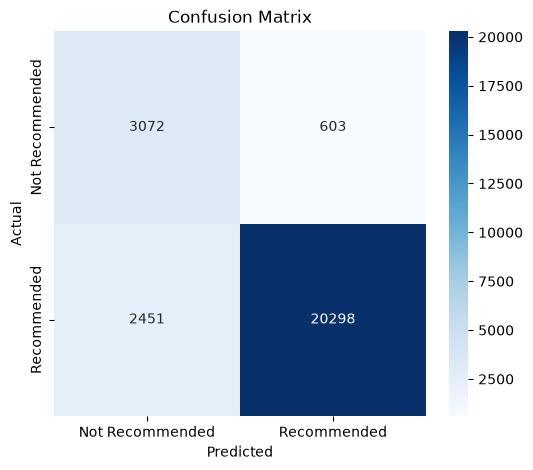

In [24]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=[False, True])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Recommended", "Recommended"],
            yticklabels=["Not Recommended", "Recommended"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
import joblib
import os

os.makedirs("../app/models", exist_ok=True)

joblib.dump(model, "../app/models/sentiment_model.pkl")
joblib.dump(vectorizer, "../app/models/tfidf_vectorizer.pkl")

['../app/models/tfidf_vectorizer.pkl']